Select a stock from the following list:
AAPL, MSFT, GOOG, AMZN, FB


Enter the symbol of the stock:  AAPL


Please choose a window size from the following options:
1. 15 days
2. 30 days
3. 90 days
4. 180 days


Enter your choice:  4


[*********************100%***********************]  2 of 2 completed


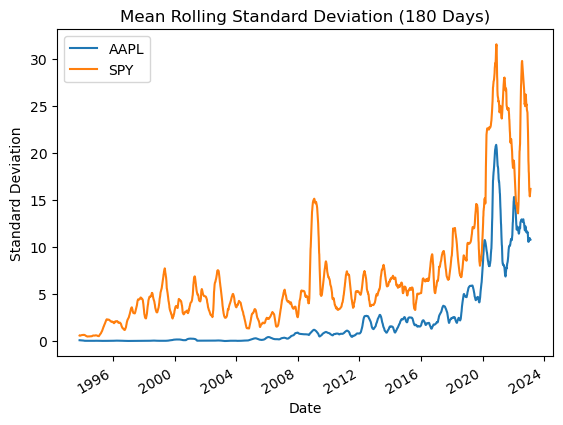

In [1]:
import datetime as dt
import pandas as pd
from pandas_datareader import data as pdr
import yfinance as yf     
import matplotlib.pyplot as plt

def  plot_rolling_std():
    # Let the user choose a stock, or symbol, from a predefined list
    stock_list = ["AAPL", "MSFT", "GOOG", "AMZN", "FB"]
    print("Select a stock from the following list:")
    print(*stock_list, sep=", ")
    symbol = input("Enter the symbol of the stock: ").upper()
    
    # let the user choose a window size from a predefined list
    window_sizes = [15, 30, 90, 180]
    print("Please choose a window size from the following options:")
    
    for i, size in enumerate(window_sizes):
        print(f"{i + 1}. {size} days")
    choice = int(input("Enter your choice: ")) - 1
    window_size = window_sizes[choice]
    
    # Get 30 year's data of the S&P 500 and the chosen stock from Yahoo Finance
    end = dt.date.today()
    start = end - dt.timedelta(days=365 * 30)
    start_date = start.strftime("%Y-%m-%d")
    end_date = end.strftime("%Y-%m-%d")
    
    stocks = ["SPY", symbol]
    
    yf.pdr_override()
    stock_data = pdr.get_data_yahoo(stocks, start_date, end_date)["Adj Close"]
    
    # Calculate rolling standard deviation and group the data by level=0
    rolling_std = stock_data.rolling(window=window_size).std()
    grouped_data = rolling_std.groupby(level=0).mean()
    
    # Plot the results
    grouped_data.plot(kind="line", title=f"Mean Rolling Standard Deviation ({window_size} Days)")
    plt.xlabel("Date")
    plt.ylabel("Standard Deviation")
    plt.show()

    return plot_rolling_std()

 